In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
from Bio import Align
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import pysam
from difflib import SequenceMatcher
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load data

In [3]:
# %%time

# fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

# adata = sc.read_h5ad(fpath)
# adata

CPU times: user 649 ms, sys: 2.41 s, total: 3.06 s
Wall time: 5.69 s


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.23 GB, difference +2.23 GB
CPU times: user 561 ms, sys: 1.91 s, total: 2.48 s
Wall time: 6.46 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/scanpy/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [3]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)
CPU times: user 2.01 s, sys: 1.54 s, total: 3.55 s
Wall time: 3.59 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


# Load cell cycle genes

In [4]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')
regev_genes = [g for g in regev_genes if g in adata.var_names]
print(f'\t in adata = {len(regev_genes)}')

# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'Total KEGG cell cycle genes: {len(kegg_genes)}')
kegg_genes = [g for g in kegg_genes if g in adata.var_names]
print(f'\t in adata = {len(kegg_genes)}')

# GO 2025
cdf = pd.read_csv("../../resources/GO_2025_cc_genes.csv")
go_cc_genes = cdf['gene'].unique()
print(f'Total GO cell cycle genes: {len(go_cc_genes)}')
go_cc_genes = [g for g in go_cc_genes if g in adata.var_names]
print(f'\t in adata = {len(go_cc_genes)}')

Total regev genes: 97
	 in adata = 94
Total KEGG cell cycle genes: 125
	 in adata = 122
Total GO cell cycle genes: 857
	 in adata = 790


In [5]:
print(len(list(set(go_cc_genes) & (set(regev_genes)))))
print(len(list(set(go_cc_genes) & (set(kegg_genes)))))
print(len(list(set(regev_genes) & (set(kegg_genes)))))

43
72
14


In [4]:
# ### --------- load cell cycle genes ---------

# # regev
# regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# print(f'Total regev genes: {len(regev_genes)}')


# # # GO
# # cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
# # cc_genes = cdf['gene_name'].unique()
# # print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')


# # KEGG (hsa04110) -- downloaded from GSEA website
# kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
# kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
# print(f'\nTotal KEGG cell cycle genes: {len(kegg_genes)}')


# ### combine into single list
# all_cc_genes = list(set(regev_genes) | set(cc_genes) | set(kegg_genes))
# print(f'\nGenes in combined list: {len(all_cc_genes)}')


# all_cc_genes = [g for g in all_cc_genes if g in adata.var_names]
# print(len(all_cc_genes))

Total regev genes: 97

Total GO cell cycle genes: 142

Total KEGG cell cycle genes: 125

Genes in combined list: 321
293


In [10]:
# ## correlation in cells across cell cycle genes / phases

# adata.obs["condition_by_phase"] = (
#     adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["phase"].astype(str)
# )

# conditions = ["Control", "mmMYOD1", "siPRRX1", "siPRRX1/mmMYOD1"]
# phases = ["G1", "S", "G2M"]

# ordered_categories = [f"{cond}_{ph}" for ph in phases for cond in conditions]

# # Apply categorical with ordering
# adata.obs["condition_by_phase"] = pd.Categorical(
#     adata.obs["condition_by_phase"],
#     categories=ordered_categories,
#     ordered=True
# )

# # Now value_counts will respect this order if you use sort=False
# adata.obs["condition_by_phase"].value_counts(sort=False)

condition_by_phase
Control_G1             3057
mmMYOD1_G1             1270
siPRRX1_G1             1238
siPRRX1/mmMYOD1_G1     1467
Control_S               412
mmMYOD1_S               398
siPRRX1_S               604
siPRRX1/mmMYOD1_S       673
Control_G2M            3433
mmMYOD1_G2M             587
siPRRX1_G2M            1841
siPRRX1/mmMYOD1_G2M    1316
Name: count, dtype: int64

# Bin MYOD expression level

In [6]:
# get log_norm counts
adata.X = adata.layers['log_norm'].copy()

mdata = adata[:, 'MYOD1'].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(X, index=mdata.obs_names, columns=mdata.var_names)

df = df.reset_index(names='cell_id')
print(df.shape)
df.head()

# get raw counts
adata.X = adata.layers['raw_counts'].copy()

mdata = adata[:, 'MYOD1'].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()
df_raw = pd.DataFrame(X, index=mdata.obs_names, columns=mdata.var_names)
df_raw = df_raw.reset_index(names='cell_id')
df_raw = df_raw.rename(columns={'MYOD1': 'MYOD1_raw'})
print(df_raw.shape)
df_raw.head()


# # merge
tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()
tmp = tmp.reset_index(names='cell_id')

df1 = pd.merge(df, tmp, how='left', on='cell_id')
df1 = pd.merge(df1, df_raw, how='left', on='cell_id')

print(df1.shape)
df1.head()

(16296, 1)
(16296, 2)
(16296, 1)
(16296, 2)
(16296, 6)


,cell_id,MYOD1,pooled_condition,leiden_split,phase,MYOD1_raw
0,AAACCAAAGCAACTGC_hybrid,2.306209,siPRRX1/mmMYOD1,H1,G2M,17.0
1,AAACCAAAGTAGGGCA_hybrid,1.635624,mmMYOD1,M1,S,4.0
2,AAACCAAAGTCTAGGC_hybrid,1.135698,siPRRX1/mmMYOD1,H1,G1,6.0
3,AAACCATTCACGTAAT_hybrid,0.000000,siPRRX1,P1,G2M,0.0
4,AAACCATTCAGGCAGA_hybrid,0.000000,siPRRX1,P1,G2M,0.0


In [7]:
# create global expression bins (enabling comparisons between conditions)

conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']

pdf = df1[df1['pooled_condition'].isin(conditions)].copy()
pdf['pooled_condition'] = pdf['pooled_condition'].astype(str)
pdf.head()

print("Total MYOD1 expression:")
print(f"Mean = {pdf['MYOD1'].mean():.4f}, Median = {pdf['MYOD1'].median()}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {pdf[pdf['MYOD1_raw'] > 0]['MYOD1'].mean():.4f}, Median = {pdf[pdf['MYOD1_raw'] > 0]['MYOD1'].median():.4f}")

Total MYOD1 expression:
Mean = 1.2979, Median = 1.2986369132995605

Among positive MYOD1 expression:
Mean = 1.4843, Median = 1.4165


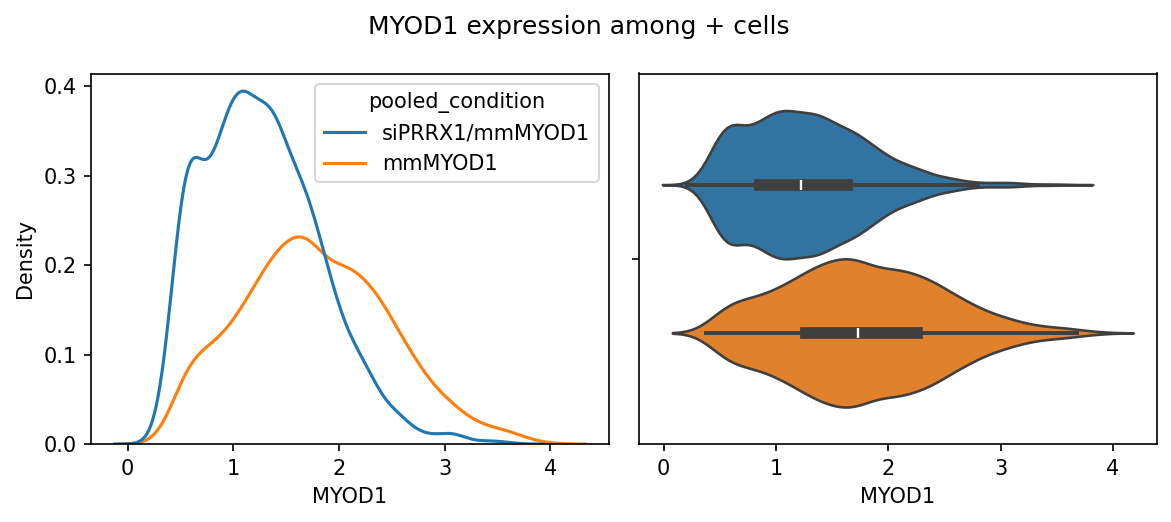

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)

sns.kdeplot(
    pdf[pdf['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='pooled_condition',
    ax=axes[0],
)

sns.violinplot(
    pdf[pdf['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='pooled_condition',
    ax=axes[1],
    legend=False,
)

plt.suptitle('MYOD1 expression among + cells')
plt.tight_layout()
plt.show()

In [13]:
## fraction MYOD1+ among conditions
conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']

umi_thresh = 0

print('Fraction of MYOD+ cells:')
for cond in conditions:
    tmp = pdf[pdf['pooled_condition'] == cond]
    myod_pos = tmp[tmp['MYOD1_raw'] > umi_thresh]
    
    print(f'\t{cond} (raw counts > {umi_thresh}): {(myod_pos.shape[0] / tmp.shape[0]):.3f}')
    print(f'\tTotal cells: {tmp.shape[0]}')
    print(f'\tMedian MYOD1 expression among + cells: {myod_pos['MYOD1'].median():.3f}\n')

Fraction of MYOD+ cells:
	mmMYOD1 (raw counts > 0): 0.937
	Total cells: 2255
	Median MYOD1 expression among + cells: 1.732

	siPRRX1/mmMYOD1 (raw counts > 0): 0.834
	Total cells: 3456
	Median MYOD1 expression among + cells: 1.221



In [62]:
exp_bins = ['LOW', 'MED', 'HIGH']

# set all to NE at first
pdf['exp_level'] = 'NE'

# obtain MYOD+ cells (raw counts)
pos_mask = pdf['MYOD1_raw'] > 0

# rank log-norm MYOD1 to break ties (important for qcut stability)
r = pdf.loc[pos_mask, 'MYOD1'].rank(method='first')

pdf.loc[pos_mask, "exp_level"] = pd.qcut(
    r,
    q=3,
    labels=exp_bins
).astype(str)

print(pdf['exp_level'].value_counts())
print(pdf.groupby('pooled_condition', observed=False)['exp_level'].value_counts())
pdf.head()

exp_level
HIGH    1665
LOW     1665
MED     1664
NE       717
Name: count, dtype: int64
pooled_condition  exp_level
mmMYOD1           HIGH         1072
                  MED           639
                  LOW           401
                  NE            143
siPRRX1/mmMYOD1   LOW          1264
                  MED          1025
                  HIGH          593
                  NE            574
Name: count, dtype: int64


,cell_id,MYOD1,pooled_condition,leiden_split,phase,MYOD1_raw,exp_level
0,AAACCAAAGCAACTGC_hybrid,2.306209,siPRRX1/mmMYOD1,H1,G2M,17.0,HIGH
1,AAACCAAAGTAGGGCA_hybrid,1.635624,mmMYOD1,M1,S,4.0,MED
2,AAACCAAAGTCTAGGC_hybrid,1.135698,siPRRX1/mmMYOD1,H1,G1,6.0,MED
5,AAACCATTCCGTAATG_hybrid,2.144668,siPRRX1/mmMYOD1,H2,G1,5.0,HIGH
6,AAACCCGCACCATAGG_hybrid,1.237847,mmMYOD1,M2,G1,3.0,MED


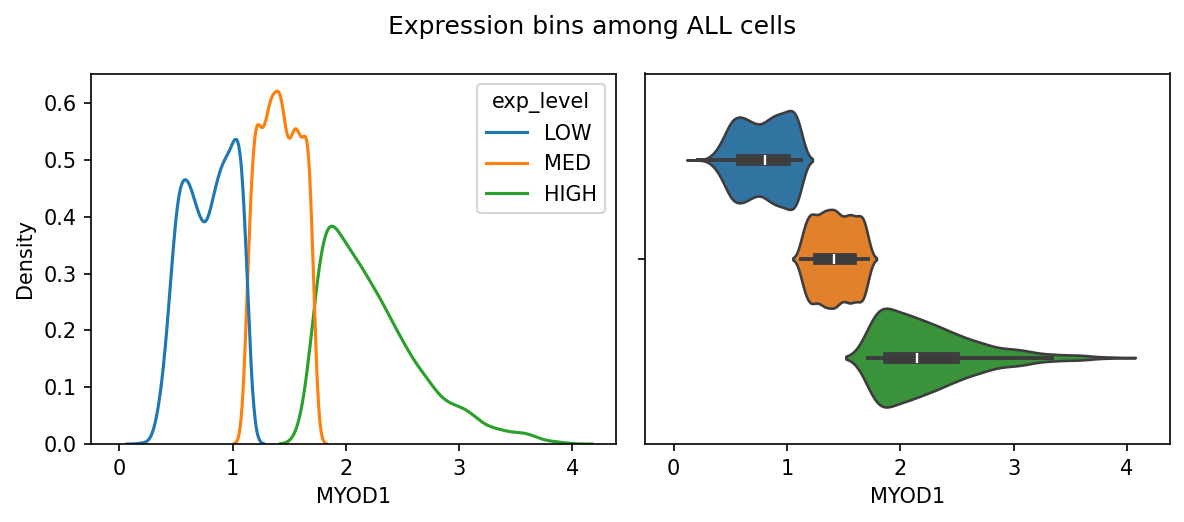

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)

xmax = pdf['MYOD1'].max()
hue_order=['LOW', 'MED', 'HIGH']

sns.kdeplot(
    pdf[pdf['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[0],
)

sns.violinplot(
    pdf[pdf['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[1],
    legend=False,
)

for ax in axes:
    ax.set_xlim(-0.25, xmax+0.5)
    
plt.suptitle('Expression bins among ALL cells')
plt.tight_layout()
plt.show()

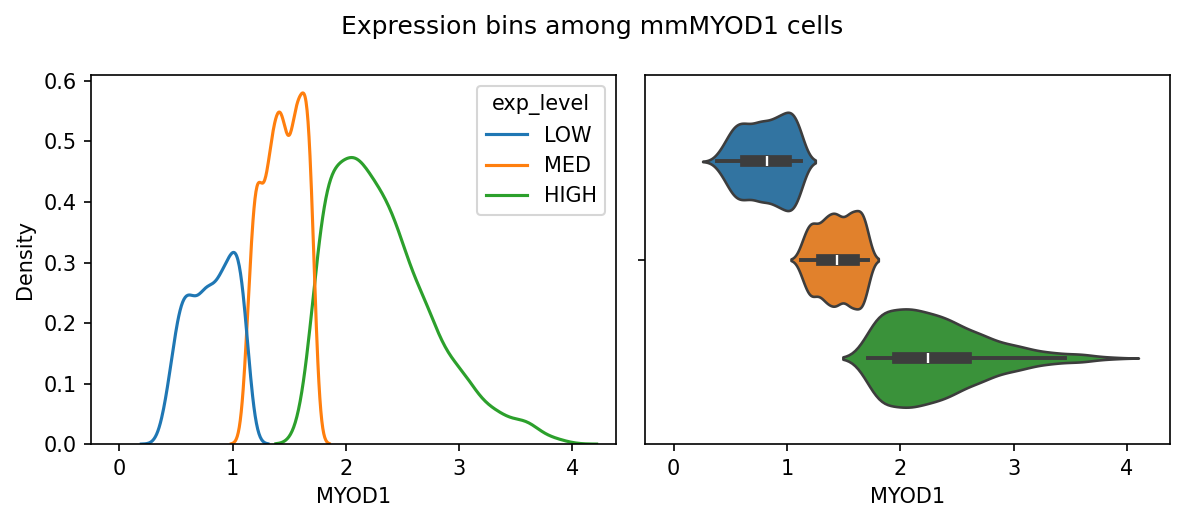

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)

tmp = pdf[pdf['pooled_condition'] == 'mmMYOD1']

sns.kdeplot(
    tmp[tmp['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[0],
)

sns.violinplot(
    tmp[tmp['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[1],
    legend=False,
)

for ax in axes:
    ax.set_xlim(-0.25, xmax+0.5)
    
plt.suptitle('Expression bins among mmMYOD1 cells')
plt.tight_layout()
plt.show()

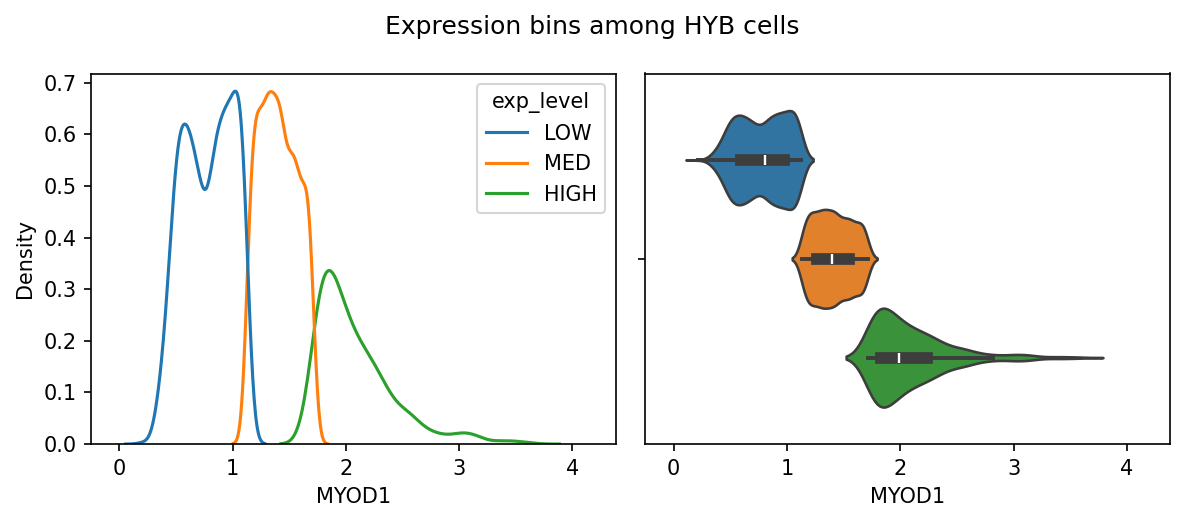

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)

tmp = pdf[pdf['pooled_condition'] == 'siPRRX1/mmMYOD1']

sns.kdeplot(
    tmp[tmp['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[0],
)

sns.violinplot(
    tmp[tmp['MYOD1_raw'] > 0],
    x='MYOD1',
    hue='exp_level',
    hue_order=hue_order,
    ax=axes[1],
    legend=False,
)

for ax in axes:
    ax.set_xlim(-0.25, xmax+0.5)
    
plt.suptitle('Expression bins among HYB cells')
plt.tight_layout()
plt.show()

In [14]:
# ### ------ get EXO/ENDO + regular MYOD1 counts ------

# adata.X = adata.layers['log_norm'].copy()


# genes = ['MYOD1_exo', 'MYOD1_endo', 'MYOD1']

# mdata = adata[:, genes].copy()
# print(mdata.shape)


# X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

# df = pd.DataFrame(
#         X,
#         index=mdata.obs_names,
#         columns=mdata.var_names,
#     )


# df = df.reset_index(names='cell_id')
# print(df.shape)
# df.head()


# tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

# tmp = tmp.reset_index(names='cell_id')


# df1 = pd.merge(df, tmp, how='left', on='cell_id')
# print(df1.shape)
# df1.head()

(16296, 3)
(16296, 4)
(16296, 7)


,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,G2M
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M


In [15]:
# ### 
# # group cells by HIGH / LOW MYOD1 expression
# pdf = df1.copy()

# pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


# print("Total MYOD1 expression:")
# print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

# print("Among positive MYOD1 expression:")
# print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# # exp_bins = ['NE', 'low', 'med', 'high']


# # pdf["exp_level"] = "NE"


# cond_col = "pooled_condition" 
# labels = ["low", "med", "high"]

# pdf["exp_level"] = "NE"

# pos_mask = pdf["avg_MYOD1"] > 0


# def assign_tertiles_within_group(s):
#     # s is avg_MYOD1 for positive cells in ONE condition
#     if s.nunique() < 2:
#         # not enough unique values to form quantiles reliably
#         return pd.Series(["med"] * len(s), index=s.index)

#     # Use rank to break ties deterministically so qcut can make equal counts
#     r = s.rank(method="first")
#     out = pd.qcut(r, q=3, labels=labels)
#     return out.astype(str)

# pdf.loc[pos_mask, "exp_level"] = (
#     pdf.loc[pos_mask]
#        .groupby(cond_col)["avg_MYOD1"]
#        .apply(assign_tertiles_within_group)
#        .reset_index(level=0, drop=True)
# )

# # checks: equal-sized tertiles per condition among positives
# print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())

Total MYOD1 expression:
Mean = 1.0107, Median = 0.0

Among positive MYOD1 expression:
Mean = 2.5790, Median = 2.6923

pooled_condition  exp_level
Control           high            0
                  low             0
                  med             0
mmMYOD1           high          749
                  low           748
                  med           748
siPRRX1           high          260
                  low           260
                  med           259
siPRRX1/mmMYOD1   high         1121
                  low          1121
                  med          1120
Name: count, dtype: int64


/tmp/ipykernel_1971264/3700120773.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cond_col)["avg_MYOD1"]
/tmp/ipykernel_1971264/3700120773.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())


In [13]:
# ### 
# # group cells by HIGH / LOW MYOD1 expression
# pdf = df1.copy()


# pdf = pdf[pdf['pooled_condition'].isin(['mmMYOD1', 'siPRRX1/mmMYOD1'])]


# pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


# print("Total MYOD1 expression:")
# print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

# print("Among positive MYOD1 expression:")
# print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# # cond_col = "pooled_condition" 
# labels = ["low", "med", "high"]

# pdf["exp_level"] = "NE"

# pos_mask = pdf["avg_MYOD1"] > 0

# # rank to break ties (important for qcut stability)
# r = pdf.loc[pos_mask, "avg_MYOD1"].rank(method="first")

# pdf.loc[pos_mask, "exp_level"] = pd.qcut(
#     r,
#     q=3,
#     labels=labels
# ).astype(str)

# print(pdf['exp_level'].value_counts())
# print(pdf.groupby('pooled_condition', observed=False)['exp_level'].value_counts())
# pdf.head()

Total MYOD1 expression:
Mean = 2.7695, Median = 2.807445509987801

Among positive MYOD1 expression:
Mean = 2.8208, Median = 2.8253

exp_level
high    1869
low     1869
med     1869
NE       104
Name: count, dtype: int64
pooled_condition  exp_level
Control           NE              0
                  high            0
                  low             0
                  med             0
mmMYOD1           high         1222
                  med           642
                  low           381
                  NE             10
siPRRX1           NE              0
                  high            0
                  low             0
                  med             0
siPRRX1/mmMYOD1   low          1488
                  med          1227
                  high          647
                  NE             94
Name: count, dtype: int64


,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase,avg_MYOD1,exp_level
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M,3.611470,high
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,G2M,3.484927,high
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1,2.416226,low
5,AAACCATTCCGTAATG_hybrid,3.385067,2.862861,2.140684,siPRRX1/mmMYOD1,H2,G2M,3.123964,med
6,AAACCCGCACCATAGG_hybrid,3.201587,2.848171,1.235015,mmMYOD1,M2,G1,3.024879,med


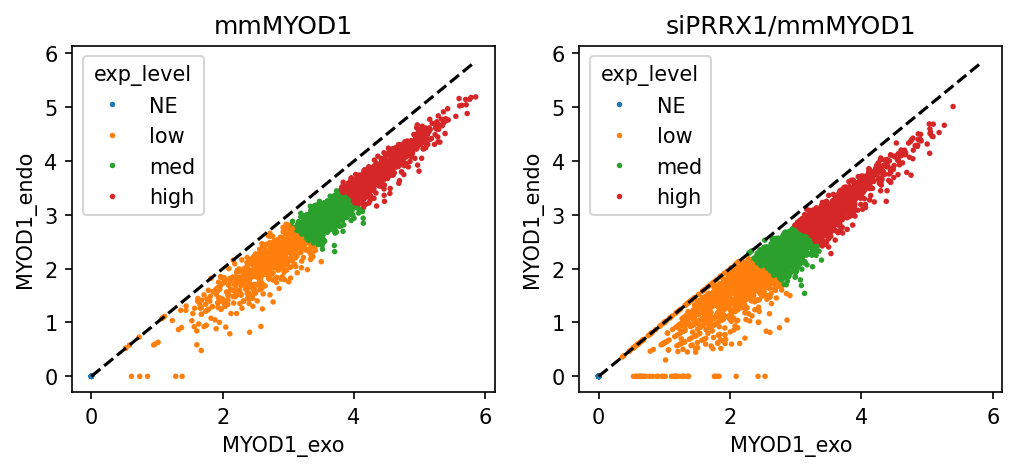

In [16]:
# fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
# axes = axes.flatten()

# conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']

# for i, cond in enumerate(conds_to_plot):
#     ax = axes[i]
    
#     tmp = pdf[pdf['pooled_condition'] == cond].copy()
    
#     sns.scatterplot(
#         tmp,
#         x='MYOD1_exo',
#         y='MYOD1_endo',
#         hue='exp_level',
#         hue_order=['NE', 'low', 'med', 'high'],
#         s=7,
#         ec='none',
#         ax=ax,
#     )
    
#     ax.set_title(f'{cond}')
    
#     # Identity line
#     min_val = min(pdf['MYOD1_exo'].min(), pdf['MYOD1_endo'].min())
#     max_val = max(pdf['MYOD1_exo'].max(), pdf['MYOD1_endo'].max())
    
#     ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black')
    
    
# plt.show()

## Assign to adata.obs

In [66]:
# make a Series indexed by cell_id
s = (pdf.set_index("cell_id")["exp_level"])

# align to adata.obs_names and add
adata.obs["exp_level"] = s.reindex(adata.obs_names)

# (optional) keep ordered categorical + desired order
exp_bins = ["NE", "LOW", "MED", "HIGH"]
adata.obs["exp_level"] = pd.Categorical(adata.obs["exp_level"],
                                        categories=exp_bins,
                                        ordered=True)

# quick sanity checks
print(adata.obs["exp_level"].isna().sum(), "cells missing exp_level (no match in pdf)")
print(adata.obs["exp_level"].value_counts(dropna=False))

10585 cells missing exp_level (no match in pdf)
exp_level
NaN     10585
HIGH     1665
LOW      1665
MED      1664
NE        717
Name: count, dtype: int64


In [67]:
adata.obs["exp_level_group"] = np.where(
    adata.obs["pooled_condition"].eq("Control"),
    "Control",
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["exp_level"].astype(str)
)

adata.obs["exp_level_group"].value_counts()

exp_level_group
Control                 6902
siPRRX1_nan             3683
siPRRX1/mmMYOD1_LOW     1264
mmMYOD1_HIGH            1072
siPRRX1/mmMYOD1_MED     1025
mmMYOD1_MED              639
siPRRX1/mmMYOD1_HIGH     593
siPRRX1/mmMYOD1_NE       574
mmMYOD1_LOW              401
mmMYOD1_NE               143
Name: count, dtype: int64

In [68]:
# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['exp_phase_group'] = (
    adata.obs['exp_level_group'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["exp_phase_group"].value_counts(sort=False)

exp_phase_group
siPRRX1/mmMYOD1_HIGH_G2M      70
mmMYOD1_MED_G1S              566
siPRRX1/mmMYOD1_MED_G1S      871
siPRRX1_nan_G2M             1281
siPRRX1/mmMYOD1_HIGH_G1S     523
mmMYOD1_LOW_G2M               52
mmMYOD1_LOW_G1S              349
siPRRX1_nan_G1S             2402
siPRRX1/mmMYOD1_NE_G1S       458
siPRRX1/mmMYOD1_LOW_G1S     1033
siPRRX1/mmMYOD1_LOW_G2M      231
mmMYOD1_HIGH_G1S             981
mmMYOD1_NE_G1S               126
mmMYOD1_HIGH_G2M              91
mmMYOD1_MED_G2M               73
siPRRX1/mmMYOD1_MED_G2M      154
mmMYOD1_NE_G2M                17
siPRRX1/mmMYOD1_NE_G2M       116
Control_G2M                 1958
Control_G1S                 4944
Name: count, dtype: int64

In [69]:
# Create the combined grouping column
adata.obs['exp_phase'] = (
    adata.obs['exp_level_group'].astype(str) + '_' +
    adata.obs['phase'].astype(str)
)

adata.obs["exp_phase"].value_counts(sort=False)

exp_phase
siPRRX1/mmMYOD1_HIGH_G2M      70
mmMYOD1_MED_S                143
siPRRX1/mmMYOD1_MED_G1       629
siPRRX1_nan_G2M             1281
siPRRX1/mmMYOD1_HIGH_G1      425
mmMYOD1_MED_G1               423
mmMYOD1_LOW_G2M               52
mmMYOD1_LOW_G1               242
siPRRX1_nan_G1              1647
siPRRX1/mmMYOD1_NE_S         159
siPRRX1/mmMYOD1_NE_G1        299
siPRRX1_nan_S                755
siPRRX1/mmMYOD1_LOW_S        381
siPRRX1/mmMYOD1_LOW_G2M      231
mmMYOD1_HIGH_G1              840
siPRRX1/mmMYOD1_HIGH_S        98
mmMYOD1_NE_S                  35
siPRRX1/mmMYOD1_MED_S        242
mmMYOD1_HIGH_G2M              91
siPRRX1/mmMYOD1_LOW_G1       652
mmMYOD1_HIGH_S               141
mmMYOD1_MED_G2M               73
siPRRX1/mmMYOD1_MED_G2M      154
mmMYOD1_LOW_S                107
mmMYOD1_NE_G1                 91
mmMYOD1_NE_G2M                17
siPRRX1/mmMYOD1_NE_G2M       116
Control_G2M                 1958
Control_G1                  4451
Control_S                    493


(16296, 2)
(16296, 10)
mmMYOD1 G1S: 1668
siPRRX1/mmMYOD1 G1S: 2140


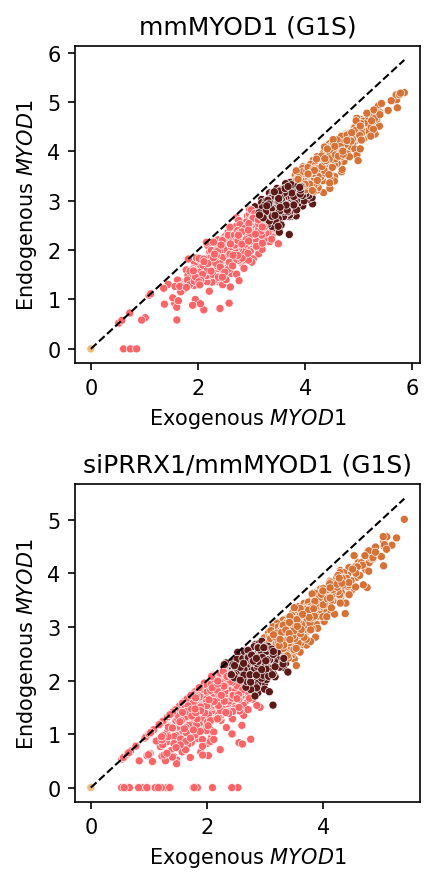

In [76]:
# groups = adata.obs[['exp_phase_group']].copy()
# groups = groups.reset_index(names='cell_id')
# print(groups.shape)

# tmp = pd.merge(df1, groups, how='left', on='cell_id')

# tmp['exp_level'] = tmp['exp_phase_group'].str.split('_').str[-2].str.upper()
# tmp['phase_group'] = tmp['exp_phase_group'].str.split('_').str[-1].str.upper()

# print(tmp.shape)
# tmp.head()

# fig, axes = plt.subplots(2, 1, figsize=(3, 6), dpi=150)
# axes = axes.flatten()

# conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']
# phase = 'G1S'

# palette = [
#     '#F1BB7B',
#     '#FD6467',
#     '#5B1A18',
#     '#D67236',
# ]

# for i, cond in enumerate(conds_to_plot):
#     ax = axes[i]
    
#     tmp1 = tmp[(tmp['pooled_condition'] == cond) & (tmp['phase_group'] == phase)].copy()
#     print(f'{cond} {phase}: {len(tmp1)}')
    
#     sns.scatterplot(
#         tmp1,
#         x='MYOD1_exo',
#         y='MYOD1_endo',
#         hue='exp_level',
#         hue_order=['NE', 'LOW', 'MED', 'HIGH'],
#         palette=palette,
#         s=15,
#         ax=ax,
#         legend=False,
#     )
    
#     ax.set_title(f'{cond} ({phase})')
#     ax.set_ylabel('Endogenous $MYOD1$')
#     ax.set_xlabel('Exogenous $MYOD1$')
    
#     # Identity line
#     min_val = min(tmp1['MYOD1_exo'].min(), tmp1['MYOD1_endo'].min())
#     max_val = max(tmp1['MYOD1_exo'].max(), tmp1['MYOD1_endo'].max())
    
#     ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black', lw=1)
    

# plt.tight_layout()
# plt.show()

# DGE G1S

In [12]:
# # G1S
# phase = 'G1S'

# groups = [f'mmMYOD1_high_{phase}', f'mmMYOD1_low_{phase}', f'mmMYOD1_med_{phase}']

# tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
# print(tmp['exp_phase_group'].value_counts())

# sc.tl.rank_genes_groups(
#     adata,
#     groupby='exp_phase_group',
#     groups=groups,
#     reference=f'Control_{phase}',
#     method='wilcoxon',
#     layer='log_norm',
#     use_raw=False,
#     pts=True,
#     key_added='myod_vs_ctrl_g1s',
# )

exp_phase_group
mmMYOD1_high_G1S    609
mmMYOD1_med_G1S     550
mmMYOD1_low_G1S     504
Name: count, dtype: int64
ranking genes


... storing 'phase' as categorical
... storing 'exp_level_group' as categorical
... storing 'phase_grouped' as categorical
... storing 'exp_phase_group' as categorical


    finished (0:00:24)


In [79]:
# # in HIGH group
# deg_key = 'myod_vs_ctrl_g1s'

# deg = sc.get.rank_genes_groups_df(
#     adata,
#     group=None,
#     key=deg_key,
# )

# deg['reference_group'] = 'Control_G1S'
# deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

# print(deg.shape)
# deg.head()

# mdf = deg[deg['pvals_adj'] < 0.05].copy()
# print(mdf.shape)
# mdf.head()

(75384, 9)
(20129, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_endo,39.417999,35.391575,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_exo,39.417999,36.277603,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,39.288548,33.273232,0.000000e+00,0.000000e+00,0.996716,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,39.286720,3.184768,0.000000e+00,0.000000e+00,0.998358,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,34.743896,3.124334,1.713625e-264,6.240575e-262,0.963875,Control_G1S,up


In [16]:
# ### HYB
# phase = 'G1S'

# groups = [f'siPRRX1/mmMYOD1_high_{phase}', f'siPRRX1/mmMYOD1_low_{phase}', f'siPRRX1/mmMYOD1_med_{phase}']

# tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
# print(tmp['exp_phase_group'].value_counts())

# sc.tl.rank_genes_groups(
#     adata,
#     groupby='exp_phase_group',
#     groups=groups,
#     reference=f'Control_{phase}',
#     method='wilcoxon',
#     layer='log_norm',
#     use_raw=False,
#     pts=True,
#     key_added='hyb_vs_ctrl_g1s',
# )

exp_phase_group
siPRRX1/mmMYOD1_high_G1S    774
siPRRX1/mmMYOD1_med_G1S     678
siPRRX1/mmMYOD1_low_G1S     641
mmMYOD1_NE_G1S                0
mmMYOD1_high_G1S              0
mmMYOD1_high_G2M              0
mmMYOD1_low_G1S               0
mmMYOD1_NE_G2M                0
Control_G1S                   0
Control_G2M                   0
mmMYOD1_med_G2M               0
mmMYOD1_med_G1S               0
mmMYOD1_low_G2M               0
siPRRX1/mmMYOD1_NE_G1S        0
siPRRX1/mmMYOD1_high_G2M      0
siPRRX1/mmMYOD1_NE_G2M        0
siPRRX1/mmMYOD1_low_G2M       0
siPRRX1/mmMYOD1_med_G2M       0
siPRRX1_NE_G1S                0
siPRRX1_NE_G2M                0
siPRRX1_high_G1S              0
siPRRX1_high_G2M              0
siPRRX1_low_G1S               0
siPRRX1_low_G2M               0
siPRRX1_med_G1S               0
siPRRX1_med_G2M               0
Name: count, dtype: int64
ranking genes
    finished (0:00:24)


In [80]:
# # in HIGH group
# deg_key = 'hyb_vs_ctrl_g1s'

# deg = sc.get.rank_genes_groups_df(
#     adata,
#     group=None,
#     key=deg_key,
# )

# deg['reference_group'] = 'Control_G1S'
# deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

# print(deg.shape)
# deg.head()

# hdf = deg[deg['pvals_adj'] < 0.05].copy()
# print(hdf.shape)
# hdf.head()

(75384, 9)
(20089, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,43.565788,34.349598,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,43.565788,35.113995,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,43.562412,2.997419,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,42.721489,32.044655,0.000000e+00,0.000000e+00,0.980620,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,36.573940,2.692000,7.426061e-293,4.339583e-290,0.970284,Control_G1S,up


# DEG G1

DE comparisons
* mmMYOD1_LOW - Control
* mmMYOD1_MED - Control
* mmMYOD1_HIGH - Control

* HYB_LOW - Control
* HYB_MED - Control
* HYB_HIGH - Control

Answers: Within each condition (mmMYOD1 and HYB), how does the DE program vs Control change across MYOD1 expression levels?


-------------------

* 0.5 x mmMYOD1_LOW + 0.5 * HYB_LOW - Control
* 0.5 x mmMYOD1_MED + 0.5 * HYB_MED - Control
* 0.5 x mmMYOD1_HIGH + 0.5 * HYB_HIGH - Control

Answers: Across both treated conditions, what is the DE program associated with LOW/MED/HIGH MYOD1 expression relative to Control?
(taking average because cell counts are drastically different between groups)

-------------------
* mmMYOD1_LOW - mmMYOD1_LOW
* mmMYOD1_MED - mmMYOD1_MED
* mmMYOD1_HIGH - mmMYOD1_HIGH
(same for HYB)

Answers: Within a given treatment, what changes as MYOD1 expression increases?

In [70]:
# G1
phase = 'G1'

groups = [f'mmMYOD1_HIGH_{phase}', f'mmMYOD1_LOW_{phase}', f'mmMYOD1_MED_{phase}']

tmp = adata.obs[adata.obs['exp_phase'].isin(groups)]
print(tmp['exp_phase'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='myod_vs_ctrl_g1',
)

exp_phase
mmMYOD1_HIGH_G1    840
mmMYOD1_MED_G1     423
mmMYOD1_LOW_G1     242
Name: count, dtype: int64
ranking genes


... storing 'phase' as categorical
... storing 'exp_level_group' as categorical
... storing 'phase_grouped' as categorical
... storing 'exp_phase_group' as categorical
... storing 'exp_phase' as categorical


    finished (0:00:39)


In [104]:
# in HIGH group
deg_key = 'myod_vs_ctrl_g1'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

mdf = deg[deg['pvals_adj'] < 0.05].copy()
print(mdf.shape)
mdf.head()

(75378, 9)
(18902, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_HIGH_G1,MYOD1,46.038288,33.159241,0.0,0.0,1.000000,Control_G1,up
1,mmMYOD1_HIGH_G1,MT-ND4,45.918354,3.045157,0.0,0.0,0.998810,Control_G1,up
2,mmMYOD1_HIGH_G1,LINC-PINT,40.165340,3.016197,0.0,0.0,0.966667,Control_G1,up
3,mmMYOD1_HIGH_G1,TAF1D,39.723000,3.025203,0.0,0.0,0.967857,Control_G1,up
4,mmMYOD1_HIGH_G1,NAV3,38.988514,3.793954,0.0,0.0,0.914286,Control_G1,up


In [72]:
### HYB
phase = 'G1'

groups = [f'siPRRX1/mmMYOD1_HIGH_{phase}', f'siPRRX1/mmMYOD1_LOW_{phase}', f'siPRRX1/mmMYOD1_MED_{phase}']

tmp = adata.obs[adata.obs['exp_phase'].isin(groups)]
tmp['exp_phase'] = tmp['exp_phase'].astype(str)
print(tmp['exp_phase'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='hyb_vs_ctrl_g1',
)

exp_phase
siPRRX1/mmMYOD1_LOW_G1     652
siPRRX1/mmMYOD1_MED_G1     629
siPRRX1/mmMYOD1_HIGH_G1    425
Name: count, dtype: int64
ranking genes


/tmp/ipykernel_3843748/449459374.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['exp_phase'] = tmp['exp_phase'].astype(str)


    finished (0:00:31)


In [105]:
# in HIGH group
deg_key = 'hyb_vs_ctrl_g1'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

hdf = deg[deg['pvals_adj'] < 0.05].copy()
print(hdf.shape)
hdf.head()

(75378, 9)
(19290, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_HIGH_G1,MYOD1,34.112026,32.776478,4.892714e-255,5.791564e-251,1.000000,Control_G1,up
1,siPRRX1/mmMYOD1_HIGH_G1,MT-ND4,34.109646,3.075970,5.306919e-255,5.791564e-251,1.000000,Control_G1,up
2,siPRRX1/mmMYOD1_HIGH_G1,NAV3,29.258612,3.757255,3.489202e-188,2.087374e-185,0.936471,Control_G1,up
3,siPRRX1/mmMYOD1_HIGH_G1,LINC-PINT,27.679758,2.701757,1.223837e-168,4.659112e-166,0.955294,Control_G1,up
4,siPRRX1/mmMYOD1_HIGH_G1,NFAT5,26.713999,3.021102,3.236930e-157,1.084415e-154,0.910588,Control_G1,up


# Load DEG tables

In [4]:
# fpath = "../../tables/DEGs_MyodExpLevels_HYB_G1S.csv"

# hdf = pd.read_csv(fpath)
# print(hdf.shape)
# display(hdf.head())



# fpath = "../../tables/DEGs_MyodExpLevels_mmMYOD1_G1S.csv"

# mdf = pd.read_csv(fpath)
# print(mdf.shape)
# display(mdf.head())

(21850, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,47.505005,35.085710,0.0,0.0,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,47.505005,34.325275,0.0,0.0,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,47.501183,2.978337,0.0,0.0,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,46.688595,32.032375,0.0,0.0,0.982814,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,38.898235,2.623778,0.0,0.0,0.963480,Control_G1S,up


(21381, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_exo,41.296528,36.265495,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_endo,41.296528,35.380703,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,41.172330,33.265804,0.000000e+00,0.000000e+00,0.996992,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,41.169952,3.180320,0.000000e+00,0.000000e+00,0.998496,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,36.189045,3.098549,9.053250e-287,3.296958e-284,0.962406,Control_G1S,up


In [74]:
all_cc_genes = list(set(go_cc_genes) | set(regev_genes) | set(kegg_genes))
print(len(all_cc_genes))

884


In [219]:
cc_gene_list = all_cc_genes.copy()
# cc_gene_list = kegg_genes.copy()
print(len(cc_gene_list))

hdf1 = hdf[hdf['names'].isin(cc_gene_list)]
print(hdf.shape)

mdf1 = mdf[mdf['names'].isin(cc_gene_list)]
print(mdf.shape)

884
(19290, 9)
(18902, 9)


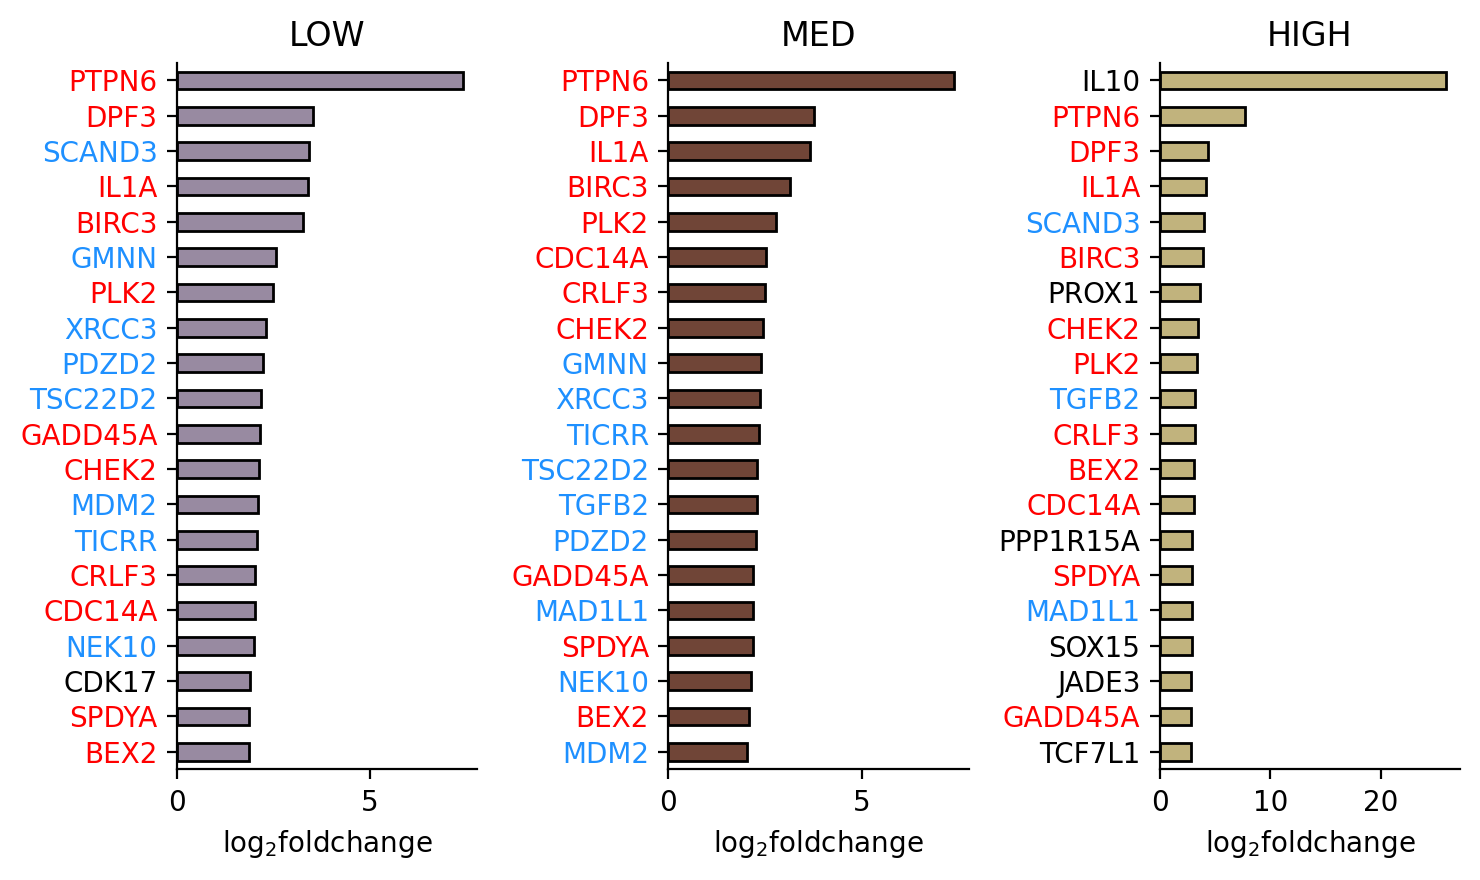

In [227]:
hdf1 = hdf1[hdf1['logfoldchanges'].abs() >= 0.5]
hdf1['exp_level'] = hdf1['group'].str.split('_').str[-2]

hdf1 = hdf1.sort_values(by='logfoldchanges', ascending=False)

from collections import Counter

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7.5, 4.5

fig, axs = plt.subplots(nrows=1, ncols=3)

n_genes = 20

top_genes_per_group = {}

plot_order = ["LOW", "MED", "HIGH"]
color_map = {
    "LOW": "#9986A5",
    "MED": "#79402E",
    "HIGH": "#CCBA72",
}

for group in plot_order:
    df = hdf1[hdf1['exp_level'] == group].sort_values(by='logfoldchanges', ascending=False)
    top_genes_per_group[group] = df.head(n_genes)['names'].tolist()

# Step 2: Count appearances across groups
gene_counts = Counter()
for gene_list in top_genes_per_group.values():
    gene_counts.update(gene_list)

# Step 3: Categorize genes
red_genes = {gene for gene, count in gene_counts.items() if count == 3}
blue_genes = {gene for gene, count in gene_counts.items() if count == 2}

for i, group in enumerate(plot_order): 
    df = hdf1[hdf1['exp_level'] == group].sort_values(by='logfoldchanges', ascending=False).head(n_genes)
    ax = axs[i]

    sns.barplot(data=df, x='logfoldchanges', y='names', ax=ax, width=0.5, color=color_map[group], ec='k')
    ax.set_title(group)
    ax.set_xlabel("log$_2$foldchange")
    ax.set_ylabel("")

    # if group == 'mmMYOD1':
    #     ax.set_xlim([0, 15])
    #     # ax.set_xscale('log')
    # elif group == 'siPRRX1/mmMYOD1':
    #     ax.set_xlim([0, 15])
    #     # ax.set_xscale('log')
    # # else:
    # #     ax.set_xlim([0, 5])

    for tick in ax.get_yticklabels():
        gene = tick.get_text()
        if gene in red_genes:
            tick.set_color('red')
            # tick.set_fontweight('semibold')
        elif gene in blue_genes:
            tick.set_color('dodgerblue')
            # tick.set_fontweight('semibold')

sns.despine()
plt.tight_layout()
plt.show()

In [220]:
df = pd.concat([mdf1, hdf1])
print(f'N unique DEGs: {df['names'].nunique()}')
print(df.shape)
df.head()

N unique DEGs: 607
(2406, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
7,mmMYOD1_HIGH_G1,GADD45A,34.372444,3.680582,6.509089e-259,1.340552e-256,0.879762,Control_G1,up
14,mmMYOD1_HIGH_G1,PPP1R15A,32.702827,3.347048,1.423642e-234,2.450029e-232,0.865476,Control_G1,up
19,mmMYOD1_HIGH_G1,IRF1,31.351063,2.456362,9.409844e-216,1.407332e-213,0.902381,Control_G1,up
36,mmMYOD1_HIGH_G1,DPF3,28.777081,5.223020,4.152499e-182,4.657844e-180,0.655952,Control_G1,up
61,mmMYOD1_HIGH_G1,UBE2E2,26.003523,2.459253,4.518144e-149,3.771524e-147,0.732143,Control_G1,up


In [221]:
df = df[df['logfoldchanges'].abs() >= 0.5]

print(f'N unique DEGs: {df['names'].nunique()}')
print(df.shape)
df.head()

N unique DEGs: 540
(1999, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
7,mmMYOD1_HIGH_G1,GADD45A,34.372444,3.680582,6.509089e-259,1.340552e-256,0.879762,Control_G1,up
14,mmMYOD1_HIGH_G1,PPP1R15A,32.702827,3.347048,1.423642e-234,2.450029e-232,0.865476,Control_G1,up
19,mmMYOD1_HIGH_G1,IRF1,31.351063,2.456362,9.409844e-216,1.407332e-213,0.902381,Control_G1,up
36,mmMYOD1_HIGH_G1,DPF3,28.777081,5.223020,4.152499e-182,4.657844e-180,0.655952,Control_G1,up
61,mmMYOD1_HIGH_G1,UBE2E2,26.003523,2.459253,4.518144e-149,3.771524e-147,0.732143,Control_G1,up


In [222]:
df.groupby('group')['names'].nunique()

group
mmMYOD1_HIGH_G1            436
mmMYOD1_LOW_G1             250
mmMYOD1_MED_G1             335
siPRRX1/mmMYOD1_HIGH_G1    353
siPRRX1/mmMYOD1_LOW_G1     312
siPRRX1/mmMYOD1_MED_G1     313
Name: names, dtype: int64

In [195]:
# per group, how many DE cell cycle genes? How many UP/DOWN

counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

display(plot_df)

vmax = plot_df.max().max()
vmin = plot_df.min().min()

# group = 'mmMYOD1'
group = 'siPRRX1/mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    plot_df = plot_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    plot_df = plot_df.tail(3)


plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction,down,up
group,,
mmMYOD1_HIGH_G1,-33,36
mmMYOD1_LOW_G1,-10,28
mmMYOD1_MED_G1,-15,32
siPRRX1/mmMYOD1_HIGH_G1,-28,27
siPRRX1/mmMYOD1_LOW_G1,-8,38
siPRRX1/mmMYOD1_MED_G1,-17,32


direction,down,up
group,,
HIGH,-28,27
LOW,-8,38
MED,-17,32


direction,down,up
group,,
LOW,-8,38
MED,-17,32
HIGH,-28,27


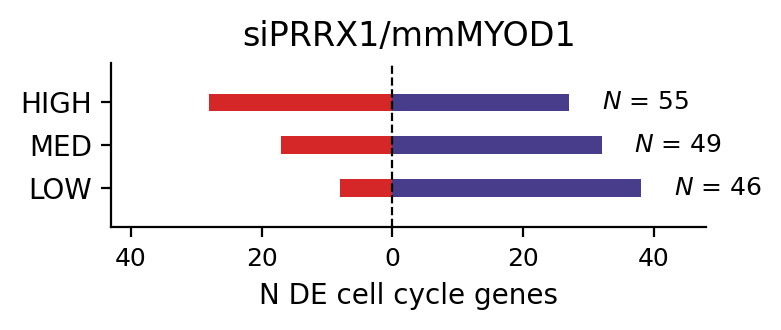

In [196]:
plot_order = ['LOW', 'MED', 'HIGH']
plot_df = plot_df.reindex(plot_order)
display(plot_df)

# plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 1.75
fig, ax = plt.subplots()

bar_width = 0.4

ax.barh(plot_df.index, plot_df['up'], color='darkslateblue', label='Up', height=bar_width)
ax.barh(plot_df.index, plot_df['down'], color='tab:red', label='Down', height=bar_width)

ax.axvline(0, color='k', linewidth=0.8, ls='--')

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_order)
ax.margins(y=0.3)


ax.set_xlim([vmin-10, vmax+10])

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: int(abs(x))))
ax.tick_params(axis='x', labelsize=9)

ax.set_title(f'{group}')

ax.set_xlabel('N DE cell cycle genes')


for i, (up, down) in enumerate(zip(plot_df['up'], plot_df['down'])):
    total = up + abs(down)
    ax.text(
        up + 5,
        i,
        f'$N$ = {str(int(total))}',
        va='center',
        ha='left',
        fontsize=9,
    )



sns.despine()
plt.tight_layout()
plt.show()

In [197]:
counts = df.groupby(['group', 'direction'], observed=True).size().reset_index(name='count')
counts['count'] = counts.apply(lambda row: -row['count'] if row['direction'] == 'down' else row['count'], axis=1)
plot_df = counts.pivot(index='group', columns='direction', values='count').fillna(0)

plot_df['total'] = -plot_df['down'] + plot_df['up']

total_cc_genes = len(cc_gene_list)
print(total_cc_genes)

plot_df['prop_of_all'] = plot_df['total'] / total_cc_genes

plot_df


122


direction,down,up,total,prop_of_all
group,,,,
mmMYOD1_HIGH_G1,-33,36,69,0.565574
mmMYOD1_LOW_G1,-10,28,38,0.311475
mmMYOD1_MED_G1,-15,32,47,0.385246
siPRRX1/mmMYOD1_HIGH_G1,-28,27,55,0.450820
siPRRX1/mmMYOD1_LOW_G1,-8,38,46,0.377049
siPRRX1/mmMYOD1_MED_G1,-17,32,49,0.401639


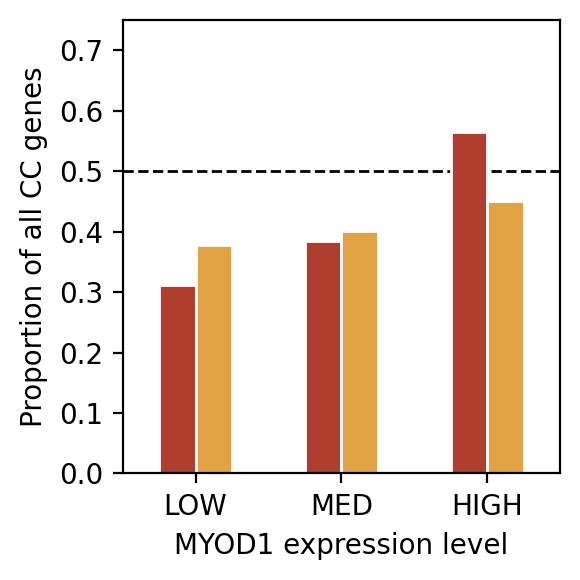

In [198]:
# Reset index for plotting
pdf = plot_df.reset_index()

pdf['condition'] = pdf['group'].str.split('_').str[0]
pdf['exp_level'] = pdf['group'].str.split('_').str[-2].str.upper()

pdf.head()


plt.figure(figsize=(3, 3), dpi=200)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.barplot(
    data=pdf,
    x='exp_level',
    y='prop_of_all',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    width=0.5,
    ec='white',
)

plt.ylim([0.0, 0.75])

plt.axhline(y=0.5, ls='--', color='k', lw=1, zorder=0)

# plt.xticks(rotation=45, ha='right')
plt.ylabel('Proportion of all CC genes')
plt.xlabel('MYOD1 expression level')
plt.tight_layout()
plt.show()

In [199]:
N = len(cc_gene_list) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

for cond in tmp['condition'].unique():
    
    print(f'{cond}:')
    
    tmp1 = tmp[tmp['condition'] == cond]
    
    high = tmp1.loc[tmp1['exp_level'] == 'HIGH', 'prop_of_all'].values[0]
    med = tmp1.loc[tmp1['exp_level'] == 'MED', 'prop_of_all'].values[0]
    low = tmp1.loc[tmp1['exp_level'] == 'LOW', 'prop_of_all'].values[0]
    
    high_low_diff = low - high
    avg_drop = ((low - med) + (med - high)) / 2
    
    print(f'Δ LOW → HIGH = {high_low_diff:.4f}')
    print(f'Δ LOW → MED = {(low - med):.4f}')
    print(f'Δ MED → HIGH = {(med - high):.4f}')
    print(f'Per-step average drop (LOW → MED, MED → HIGH) = {avg_drop:.4f}\n')


mmMYOD1:
Δ LOW → HIGH = -0.2541
Δ LOW → MED = -0.0738
Δ MED → HIGH = -0.1803
Per-step average drop (LOW → MED, MED → HIGH) = -0.1270

siPRRX1/mmMYOD1:
Δ LOW → HIGH = -0.0738
Δ LOW → MED = -0.0246
Δ MED → HIGH = -0.0492
Per-step average drop (LOW → MED, MED → HIGH) = -0.0369



In [139]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [200]:
N = len(cc_gene_list) # total number of cell cycle genes tested

tmp = plot_df.copy()
tmp = tmp.reset_index()

tmp['exp_level'] = tmp['group'].str.split('_').str[-2].str.upper()
tmp['condition'] = tmp['group'].str.split('_').str[-3]

level_map = {'LOW': 0, 'MED': 1, 'HIGH': 2}

tmp['level_ord'] = tmp['exp_level'].map(level_map)

tmp['fail'] = N - tmp['total'] # number of non-DEGs

# Main-effects model: one overall monotonic trend + condition shift
m1 = smf.glm('prop_of_all ~ level_ord + C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))  # treat each row as N trials
            ).fit()

print(m1.summary())

# Quantifying number: odds ratio per one-step increase (LOW->MED or MED->HIGH)
beta = m1.params['level_ord']
se = m1.bse['level_ord']
OR = np.exp(beta)
CI = np.exp([beta - 1.96*se, beta + 1.96*se])
print("OR per MYOD1 level step:", OR, "95% CI:", CI)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            prop_of_all   No. Observations:                    6
Model:                            GLM   Df Residuals:                      729
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -322.35
Date:                Thu, 14 May 2026   Deviance:                       4.9888
Time:                        15:30:18   Pearson chi2:                     5.00
No. Iterations:                     4   Pseudo R-squ. (CS):             0.8974
Covariance Type:            nonrobust                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:
# C(condition)[T.siPRRX1/mmMYOD1] -- condition effect (coef = % odds of a cc gene being DE compared with mmMYOD1 only)
# level_ord -- OR = % increase in the odds that a cell cycle gene is DEG going from LOW to MED or MED to HIGH after adjusting for condition

In [201]:
pred_grid = pd.DataFrame({
    'level_ord': [0,1,2]*2,
    'condition': ['mmMYOD1']*3 + ['siPRRX1/mmMYOD1']*3
})
pred = m1.get_prediction(pred_grid).summary_frame()
pred_grid['p_hat'] = pred['mean']
pred_grid['p_lo']  = pred['mean_ci_lower']
pred_grid['p_hi']  = pred['mean_ci_upper']
print(pred_grid)

   level_ord        condition     p_hat      p_lo      p_hi
0          0          mmMYOD1  0.339230  0.279069  0.405074
1          1          mmMYOD1  0.419270  0.369271  0.470983
2          2          mmMYOD1  0.503795  0.435726  0.571724
3          0  siPRRX1/mmMYOD1  0.329028  0.269703  0.394357
4          1  siPRRX1/mmMYOD1  0.408148  0.358469  0.459777
5          2  siPRRX1/mmMYOD1  0.492332  0.424482  0.560466


In [202]:
m2 = smf.glm('prop_of_all ~ level_ord * C(condition)',
             data=tmp,
             family=sm.families.Binomial(),
             freq_weights=np.repeat(N, len(tmp))
            ).fit()

# Likelihood ratio test: does interaction improve fit?
lr = 2*(m2.llf - m1.llf)
df_diff = m2.df_model - m1.df_model
from scipy.stats import chi2
p = chi2.sf(lr, df_diff)
print("LR test interaction p =", p)

LR test interaction p = 0.041484509227761174


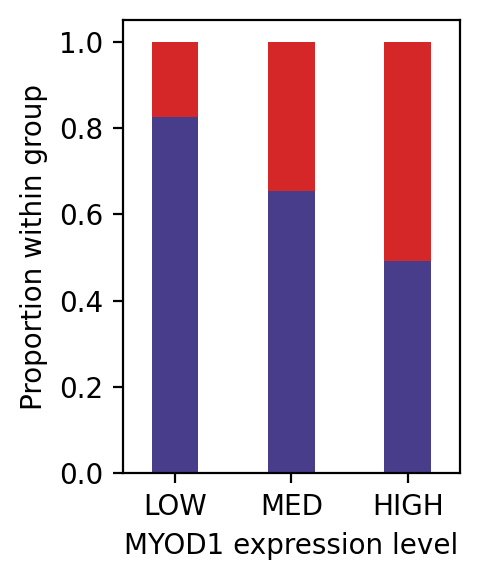

In [203]:
prop_df = plot_df.copy()

prop_df['up_prop'] = prop_df['up'] / prop_df['total']
prop_df['down_prop'] = (-prop_df['down']) / prop_df['total']  # flip sign back

# Keep only what we need
prop_df = prop_df[['up_prop', 'down_prop']]

group = 'siPRRX1/mmMYOD1'
# group = 'mmMYOD1'

if group == 'mmMYOD1':
    ## mmMYOD1
    prop_df = prop_df.head(3)
if group == 'siPRRX1/mmMYOD1':
    prop_df = prop_df.tail(3)


prop_df.index = prop_df.index.str.split('_').str[-2].str.upper() 
prop_df = prop_df.reindex(['LOW', 'MED', 'HIGH'])

plt.figure(figsize=(2.5, 3), dpi=200)

palette = ['darkslateblue', 'tab:red']

# Plot stacked bars
prop_df.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(),
    legend=False,
    color=palette,
    width=0.4,
)

plt.xticks(rotation=0)
plt.ylabel('Proportion within group')
plt.xlabel('MYOD1 expression level')


plt.tight_layout()
plt.show()

In [204]:
### within each group, how correlated are logFCs for the same genes

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
7,mmMYOD1_HIGH_G1,GADD45A,34.372444,3.680582,6.509089e-259,1.340552e-256,0.879762,Control_G1,up
226,mmMYOD1_HIGH_G1,MYC,19.091795,2.772197,2.954424e-81,1.117965e-79,0.541667,Control_G1,up
448,mmMYOD1_HIGH_G1,ATR,15.031091,1.778887,4.593774e-51,1.068733e-49,0.513095,Control_G1,up
507,mmMYOD1_HIGH_G1,MDM2,14.268490,1.689565,3.439458e-46,7.243908e-45,0.541667,Control_G1,up
543,mmMYOD1_HIGH_G1,GADD45B,13.857169,1.480973,1.151259e-43,2.304903e-42,0.652381,Control_G1,up


In [205]:
df['condition'] = df['group'].str.split('_').str[0]
df['exp_level'] = df['group'].str.split('_').str[-2].str.upper()

df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
7,mmMYOD1_HIGH_G1,GADD45A,34.372444,3.680582,6.509089e-259,1.340552e-256,0.879762,Control_G1,up,mmMYOD1,HIGH
226,mmMYOD1_HIGH_G1,MYC,19.091795,2.772197,2.954424e-81,1.117965e-79,0.541667,Control_G1,up,mmMYOD1,HIGH
448,mmMYOD1_HIGH_G1,ATR,15.031091,1.778887,4.593774e-51,1.068733e-49,0.513095,Control_G1,up,mmMYOD1,HIGH
507,mmMYOD1_HIGH_G1,MDM2,14.268490,1.689565,3.439458e-46,7.243908e-45,0.541667,Control_G1,up,mmMYOD1,HIGH
543,mmMYOD1_HIGH_G1,GADD45B,13.857169,1.480973,1.151259e-43,2.304903e-42,0.652381,Control_G1,up,mmMYOD1,HIGH


In [145]:
from scipy.stats import pearsonr, spearmanr

In [206]:
# cond = 'mmMYOD1'
cond = 'siPRRX1/mmMYOD1'

tmp = df[df['condition'] == cond].copy()

high = tmp[tmp['exp_level'] == 'HIGH']['names'].unique()
med = tmp[tmp['exp_level'] == 'MED']['names'].unique()
low = tmp[tmp['exp_level'] == 'LOW']['names'].unique()

shared_genes = list(set(high) & set(med) & set(low))
print(len(shared_genes))


tmp = tmp[tmp['names'].isin(shared_genes)]

wdf = (
    tmp[["names", "exp_level", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "exp_level"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="exp_level", values="logfoldchanges")
      .rename(columns={
          'LOW':  "logFC_low",
          'MED':  "logFC_med",
          'HIGH': "logFC_high",
      })
)

print(wdf.shape)
wdf.head() 

32
(32, 3)


exp_level,logFC_high,logFC_low,logFC_med
names,,,
ABL1,1.563344,0.970089,1.181174
ANAPC1,1.650031,1.505846,1.519976
ANAPC10,0.689295,0.789591,0.639472
ANAPC11,-1.284400,-0.516839,-0.699022
ANAPC13,0.903222,0.631508,0.702930


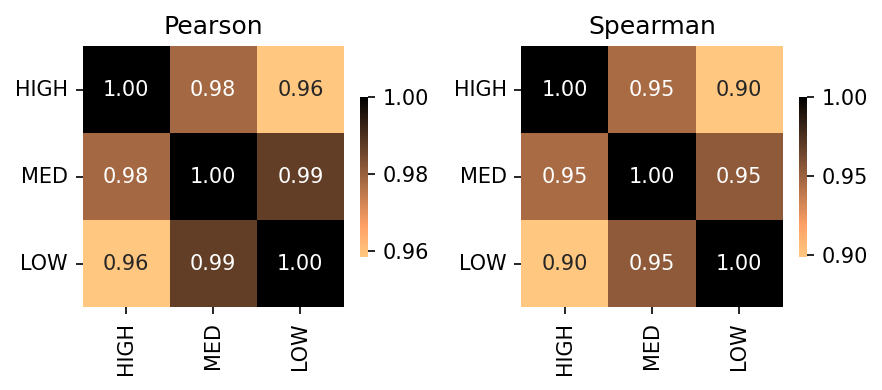

In [207]:
corr_p = wdf.corr(method='pearson')
corr_s = wdf.corr(method='spearman')

label_map = {
    'logFC_high': 'HIGH',
    'logFC_med': 'MED',
    'logFC_low': 'LOW',
}

row_order = ['logFC_high', 'logFC_med', 'logFC_low']
corr_p = corr_p.loc[row_order, row_order]
corr_s = corr_s.loc[row_order, row_order]

corr_p = corr_p.rename(index=label_map, columns=label_map)
corr_s = corr_s.rename(index=label_map, columns=label_map)

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), dpi=150)

cbar_kws = {'shrink': 0.6}
cmap = "copper_r"

sns.heatmap(corr_p, annot=True, fmt=".2f", cmap=cmap, cbar=True, square=True, cbar_kws=cbar_kws, ax=axes[0])
axes[0].set_title('Pearson')
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap=cmap, cbar=True, square=True, cbar_kws=cbar_kws, ax=axes[1])
axes[1].set_title('Spearman')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')


plt.tight_layout()
plt.show()

In [20]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level
11,mmMYOD1_high_G1S,GADD45A,30.761957,3.718991,8.461841e-208,1.446457e-205,0.872180,Control_G1S,up,mmMYOD1,HIGH
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH


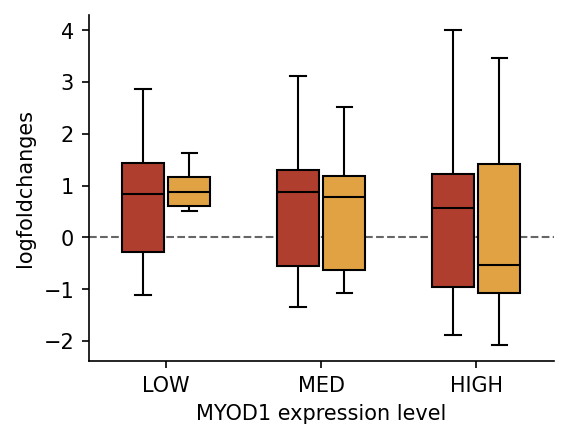

In [208]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='logfoldchanges',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

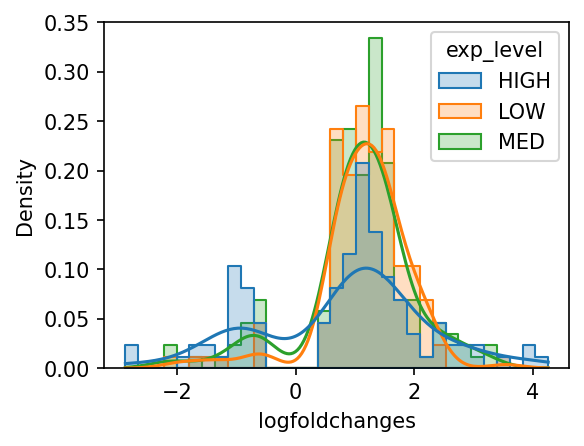

In [40]:
plt.figure(figsize=(4, 3), dpi=150)

cond = 'mmMYOD1'

tmp = df[df['condition'] == cond]

sns.histplot(
    tmp,
    x='logfoldchanges',
    kde=True,
    hue='exp_level',
    element='step',
    stat='density',
)

plt.show()

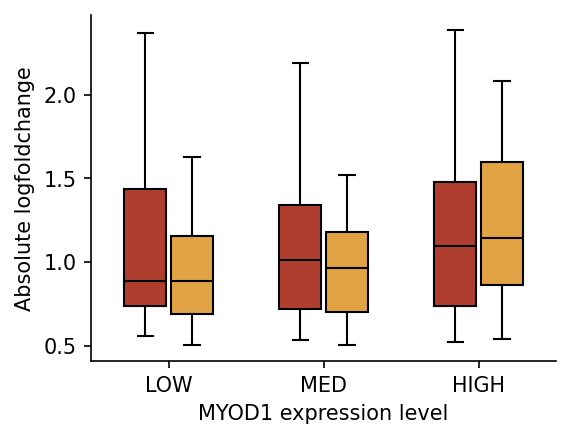

In [210]:
df['abs_lfc'] = df['logfoldchanges'].apply(abs)

plt.figure(figsize=(4, 3), dpi=150)

colors = {'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A'}

sns.boxplot(
    df,
    x='exp_level',
    y='abs_lfc',
    hue='condition',
    order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('MYOD1 expression level')
plt.ylabel('Absolute logfoldchange')
# plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

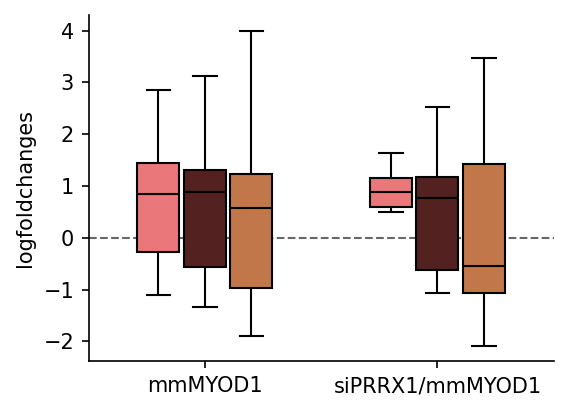

In [211]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='logfoldchanges',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')

plt.axhline(y=0, ls='--', color='k', lw=1, alpha=0.6, zorder=0)

sns.despine()
plt.show()

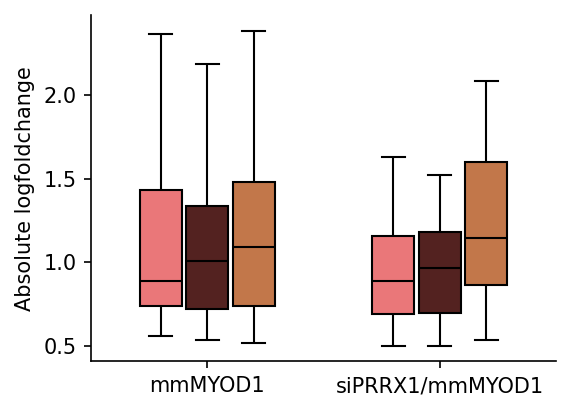

In [212]:
plt.figure(figsize=(4, 3), dpi=150)

colors = {
    'LOW': '#FD6467',
    'MED': '#5B1A18',
    'HIGH': '#D67236',
}

sns.boxplot(
    df,
    x='condition',
    y='abs_lfc',
    hue='exp_level',
    hue_order=['LOW', 'MED', 'HIGH'],
    palette=colors,
    legend=False,
    showfliers=False, 
    gap=0.1,
    width=0.6,
    linecolor='k',
    capwidths=0.1,
)

plt.xlabel('')
plt.ylabel('Absolute logfoldchange')

sns.despine()
plt.show()

In [39]:
df.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
73,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,Control_G1S,up,mmMYOD1,HIGH,2.295428
113,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,Control_G1S,up,mmMYOD1,HIGH,3.490016
202,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,Control_G1S,up,mmMYOD1,HIGH,2.351126
208,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,Control_G1S,up,mmMYOD1,HIGH,2.979373
399,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,Control_G1S,up,mmMYOD1,HIGH,1.147300


In [153]:
# group_key = 'mmMYOD1'
group_key = 'siPRRX1/mmMYOD1'
phase = 'G1'

groups_keep = [f'{group_key}_LOW_{phase}', f'{group_key}_HIGH_{phase}']

direction = 'down'

tmp = df[df['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_LOW_{phase}':  "logFC_low",
          f'{group_key}_HIGH_{phase}': "logFC_high",
      })
)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(166, 2)


group,logFC_high,logFC_low
names,,
ACTL6A,0.879499,NaN
ADAMTS1,0.536764,NaN
ANAPC11,1.284400,0.516839
ANAPC15,0.992124,NaN
ANAPC16,1.043334,0.744126


N shared downregulated genes: 50
(50, 3)


group,logFC_high,logFC_low,delta_high_low
names,,,
ANAPC11,1.284400,0.516839,0.767561
ANAPC16,1.043334,0.744126,0.299209
APP,2.093244,1.822277,0.270966
APPL1,1.836131,1.354930,0.481201
ASNS,0.610227,0.784567,-0.174340


% stronger in HIGH: 78.00%



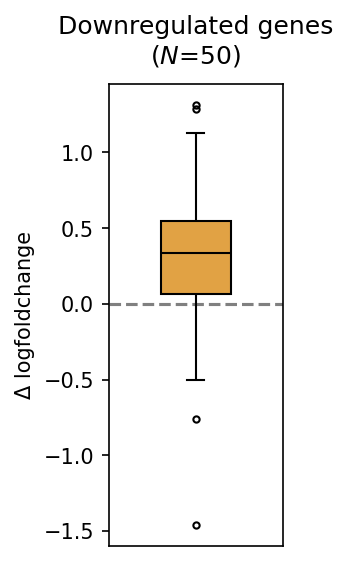

In [154]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
print(f'N shared {direction}regulated genes: {len(wdf1)}')

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

if group_key == 'mmMYOD1':
    color = '#C52E19'
elif group_key == 'siPRRX1/mmMYOD1':
    color = '#FBA72A'
else:
    color='white'

    
wdf2 = wdf1.copy()
wdf2['pos_delta'] = wdf2['delta_high_low'] > 0
print(f"% stronger in HIGH: {wdf2['pos_delta'].sum()/len(wdf2)*100:.2f}%\n")

plt.figure(figsize=(1.5, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.4,
    color=color,
    linecolor='k',
    fliersize=3,
    capwidths=0.1,
    # showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray', zorder=0)

if direction == 'up':
    plt.title(f"Upregulated genes\n($N$={len(wdf1)})", pad=10)
    
if direction == 'down':
    plt.title(f"Downregulated genes\n($N$={len(wdf1)})", pad=10)
    
plt.show()

In [ ]:
### upset plots for matches/mismatches / unique 

In [159]:
group_key = 'siPRRX1/mmMYOD1'
# group_key = 'mmMYOD1'

groups_keep = [f'{group_key}_LOW_{phase}', f'{group_key}_HIGH_{phase}']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(665, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,siPRRX1/mmMYOD1_HIGH_G1,PHACTR4,20.422188,1.874382,1.062000e-92,1.397059e-90,0.868235,Control_G1,up,siPRRX1/mmMYOD1,HIGH,1.874382,match
1,siPRRX1/mmMYOD1_HIGH_G1,IRF1,18.702156,2.084723,4.754310e-78,4.816806e-76,0.863529,Control_G1,up,siPRRX1/mmMYOD1,HIGH,2.084723,match
2,siPRRX1/mmMYOD1_HIGH_G1,HMGA2,18.530720,1.942522,1.167172e-76,1.150053e-74,0.823529,Control_G1,up,siPRRX1/mmMYOD1,HIGH,1.942522,match
3,siPRRX1/mmMYOD1_HIGH_G1,PPP1R15A,18.522406,2.942519,1.362120e-76,1.336900e-74,0.795294,Control_G1,up,siPRRX1/mmMYOD1,HIGH,2.942519,match
4,siPRRX1/mmMYOD1_HIGH_G1,GADD45A,18.245855,2.811775,2.232121e-74,2.092697e-72,0.778824,Control_G1,up,siPRRX1/mmMYOD1,HIGH,2.811775,match


In [160]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

444

 group
siPRRX1/mmMYOD1_HIGH_G1    353
siPRRX1/mmMYOD1_LOW_G1     312
Name: names, dtype: int64

 group                    direction
siPRRX1/mmMYOD1_HIGH_G1  down         163
                         up           190
siPRRX1/mmMYOD1_LOW_G1   down          53
                         up           259
Name: names, dtype: int64

 group                    direction_consistency
siPRRX1/mmMYOD1_HIGH_G1  match                    221
                         unique_to_group          132
siPRRX1/mmMYOD1_LOW_G1   match                    221
                         unique_to_group           91
Name: count, dtype: int64


In [161]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-2].str.upper() 

plot_df

direction_consistency,match,unique_to_group
group,,
HIGH,221,132
LOW,221,91


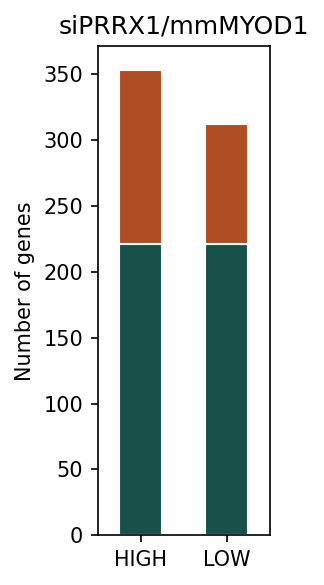

In [162]:
fig, ax = plt.subplots(figsize=(2, 4), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'{group_key}')
ax.tick_params(axis='x', rotation=0)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,siPRRX1/mmMYOD1_high_G1S,siPRRX1/mmMYOD1_low_G1S
MCM6,-0.694308,0.580596


(1, 2)


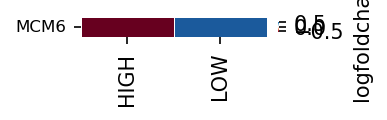

In [175]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["HIGH", "LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [184]:
dir_key = 'med'

groups_keep = [f'mmMYOD1_{dir_key}_G1S', f'siPRRX1/mmMYOD1_{dir_key}_G1S']

kdf = df[df['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

display(kdf.head())


print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

print("\n", kdf.groupby('group')['direction_consistency'].value_counts())

(308, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc,direction_consistency
0,mmMYOD1_med_G1S,GMNN,28.870295,3.202431,2.818801e-183,8.637907e-181,0.894545,Control_G1S,up,mmMYOD1,MED,3.202431,match
1,mmMYOD1_med_G1S,GADD45A,24.800114,3.225195,8.939563e-136,1.559954e-133,0.845455,Control_G1S,up,mmMYOD1,MED,3.225195,match
2,mmMYOD1_med_G1S,NES,21.430935,2.586268,6.878500e-102,7.965112e-100,0.714545,Control_G1S,up,mmMYOD1,MED,2.586268,match
3,mmMYOD1_med_G1S,CCND1,17.289200,1.163202,5.673378e-67,3.771445e-65,0.914545,Control_G1S,up,mmMYOD1,MED,1.163202,match
4,mmMYOD1_med_G1S,NASP,15.806744,1.241419,2.795484e-56,1.466491e-54,0.860000,Control_G1S,up,mmMYOD1,MED,1.241419,match


185

 group
mmMYOD1_med_G1S            151
siPRRX1/mmMYOD1_med_G1S    157
Name: names, dtype: int64

 group                    direction
mmMYOD1_med_G1S          down          16
                         up           135
siPRRX1/mmMYOD1_med_G1S  down           9
                         up           148
Name: names, dtype: int64

 group                    direction_consistency
mmMYOD1_med_G1S          match                    123
                         unique_to_group           28
siPRRX1/mmMYOD1_med_G1S  match                    123
                         unique_to_group           34
Name: count, dtype: int64


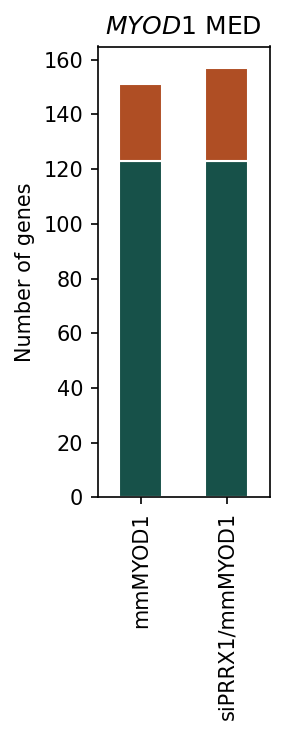

In [185]:
counts = kdf.groupby(['group', 'direction_consistency'], observed=True).size().reset_index(name='count')
plot_df = counts.pivot(index='group', columns='direction_consistency', values='count').fillna(0)

plot_df.index = plot_df.index.str.split('_').str[-3]

plot_df

fig, ax = plt.subplots(figsize=(2, 5), dpi=150)

colors = {
    'match': '#175149',
    'mismatch': '#54D8B1',
    'unique_to_group': '#AF4E24',
}

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax,
    color=colors,
    ec='white',
)

ax.set_ylabel('Number of genes')
ax.set_xlabel('')
ax.set_title(f'$MYOD1$ {dir_key.upper()}')
ax.tick_params(axis='x', rotation=90)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

,mmMYOD1_high_G1S,siPRRX1/mmMYOD1_high_G1S
BIRC5,-0.588815,0.621688
DLGAP5,-1.016875,0.626647


(2, 2)


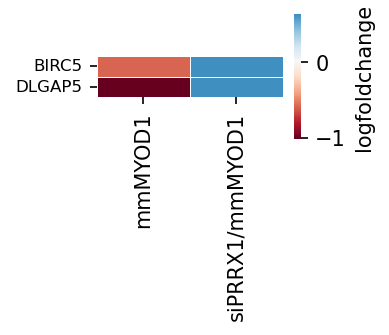

In [40]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head())
print(mdf.shape)

vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

# plt.figure(figsize=(2, 3.5), dpi=150)
plt.figure(figsize=(2, len(mdf)*0.18), dpi=150)
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    # cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    cbar_kws={"label": "logfoldchange", 'shrink': 3},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["mmMYOD1", "siPRRX1/mmMYOD1"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center', rotation=0)


plt.tight_layout()
plt.show()

# Stats

In [163]:
print(df.shape)
df.head()

(1999, 12)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction,condition,exp_level,abs_lfc
7,mmMYOD1_HIGH_G1,GADD45A,34.372444,3.680582,6.509089e-259,1.340552e-256,0.879762,Control_G1,up,mmMYOD1,HIGH,3.680582
14,mmMYOD1_HIGH_G1,PPP1R15A,32.702827,3.347048,1.423642e-234,2.450029e-232,0.865476,Control_G1,up,mmMYOD1,HIGH,3.347048
19,mmMYOD1_HIGH_G1,IRF1,31.351063,2.456362,9.409844e-216,1.407332e-213,0.902381,Control_G1,up,mmMYOD1,HIGH,2.456362
36,mmMYOD1_HIGH_G1,DPF3,28.777081,5.223020,4.152499e-182,4.657844e-180,0.655952,Control_G1,up,mmMYOD1,HIGH,5.223020
61,mmMYOD1_HIGH_G1,UBE2E2,26.003523,2.459253,4.518144e-149,3.771524e-147,0.732143,Control_G1,up,mmMYOD1,HIGH,2.459253


In [164]:
from scipy import stats
from itertools import combinations
from scipy.stats import shapiro, levene

In [165]:
# test normality, test homogeneity of variance

def normality_check(df, alpha=0.05, lfc_col='logfoldchanges', group_col='exp_level'):
    
    exp_levels = df[group_col].unique()
    
    for level in exp_levels:
        
        lfc = df[df[group_col] == level][lfc_col]
        
        stat1, p1 = stats.shapiro(lfc) # Shapiro-Wilk test
        stat2, p2 = stats.normaltest(lfc) # D’Agostino and Pearson’s test
        
        if p1 < alpha:
            sig1 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig1 = 'NOT SIGNIFICANT (data is normal)'
            
        if p2 < alpha:
            sig2 = 'SIGNIFICANT (data is NOT normal)'
        else:
            sig2 = 'NOT SIGNIFICANT (data is normal)'
        
        print(f'{level}:\tShapiro-Wilk p-val = {p1:.4e} {sig1},\tD’Agostino and Pearson’s p-val = {p2:.4e} {sig2}')

In [213]:
### mmMYOD1
tmp1 = df[df['condition'] == 'mmMYOD1'].copy()
print(tmp1.shape)

print('\n-------------- mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp1)

print('\n-------------- mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp1, lfc_col='abs_lfc')



### siPRRX1/mmMYOD1
tmp2 = df[df['condition'] == 'siPRRX1/mmMYOD1'].copy()
print(tmp2.shape)

print('\n-------------- siPRRX1/mmMYOD1 (raw logFC) --------------')
# raw logFC vals
normality_check(tmp2)

print('\n-------------- siPRRX1/mmMYOD1 (absolute logFC) --------------')
# raw logFC vals
normality_check(tmp2, lfc_col='abs_lfc')

(154, 12)

-------------- mmMYOD1 (raw logFC) --------------
HIGH:	Shapiro-Wilk p-val = 1.0478e-03 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.3594e-01 NOT SIGNIFICANT (data is normal)
LOW:	Shapiro-Wilk p-val = 2.2503e-02 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 5.4628e-01 NOT SIGNIFICANT (data is normal)
MED:	Shapiro-Wilk p-val = 1.2501e-02 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 3.7075e-01 NOT SIGNIFICANT (data is normal)

-------------- mmMYOD1 (absolute logFC) --------------
HIGH:	Shapiro-Wilk p-val = 5.9580e-08 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 6.7804e-09 SIGNIFICANT (data is NOT normal)
LOW:	Shapiro-Wilk p-val = 6.9038e-05 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 6.2688e-04 SIGNIFICANT (data is NOT normal)
MED:	Shapiro-Wilk p-val = 1.6560e-05 SIGNIFICANT (data is NOT normal),	D’Agostino and Pearson’s p-val = 1.7762e-05 SIGNIFICANT (data is NOT n

In [214]:
def manual_step_a(df, lfc_col='logfoldchanges', group_col='exp_level'):
    groups = df[group_col].unique()
    group_data = [df[df[group_col] == g][lfc_col] for g in groups]
    
    l_stat, l_p = stats.levene(*group_data)
    if l_p < 0.05:
        sig = 'SIGNIFICANT (unequal variances)'
    else:
        sig = 'NOT SIGNIFICANT (equal variances)'
    
    print(f"Levene's p-val: {l_p:.4e} {sig}")
    
    
    # 1. Global Test
    h_stat, p_global = stats.kruskal(*group_data)
    if p_global < 0.05:
        sig1 = 'SIGNIFICANT'
    else:
        sig1 = 'NOT SIGNIFICANT'
    
    print(f"Global Kruskal-Wallis p-value: {p_global:.4e} {sig1}\n") ### are any of the 3 groups (exp_levels) different?
    
    if p_global < 0.05:
        print("--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---") ### comparing the "rank" (median) between 2 specific groups
        pairs = list(combinations(groups, 2))
        num_comparisons = len(pairs)
        
        for g1, g2 in pairs:
            d1 = df[df[group_col] == g1][lfc_col]
            d2 = df[df[group_col] == g2][lfc_col]
            
            stat, p_unadj = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            # stat, p_unadj = stats.mannwhitneyu(d1, d2, alternative='greater')
            
            # Manual Bonferroni Correction
            p_adj = min(p_unadj * num_comparisons, 1.0)
            
            print(f"{g1} vs {g2}: p-unadj={p_unadj:.4e}, p-adj={p_adj:.4e}")

In [215]:
### within condition (diffs between LOW/MED/HIGH)
print("Testing for differences between MYOD1 expression levels within each condition...\n")


### mmMYOD1
print("------------ mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp1)
print("Absolute logfoldchanges:")
manual_step_a(tmp1, lfc_col='abs_lfc')


### siPRRX1mmMYOD1
print("\n------------ siPRRX1/mmMYOD1 ------------")
print("Raw logfoldchanges:")
manual_step_a(tmp2)
print("\n")
print("Absolute logfoldchanges:")
manual_step_a(tmp2, lfc_col='abs_lfc')

Testing for differences between MYOD1 expression levels within each condition...

------------ mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 6.3767e-03 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 1.3800e-01 NOT SIGNIFICANT

Absolute logfoldchanges:
Levene's p-val: 7.0824e-01 NOT SIGNIFICANT (equal variances)
Global Kruskal-Wallis p-value: 7.3861e-01 NOT SIGNIFICANT


------------ siPRRX1/mmMYOD1 ------------
Raw logfoldchanges:
Levene's p-val: 6.7968e-06 SIGNIFICANT (unequal variances)
Global Kruskal-Wallis p-value: 1.0726e-01 NOT SIGNIFICANT



Absolute logfoldchanges:
Levene's p-val: 6.3658e-02 NOT SIGNIFICANT (equal variances)
Global Kruskal-Wallis p-value: 5.0630e-03 SIGNIFICANT

--- Pairwise Mann-Whitney U Tests (with Bonferroni) ---
HIGH vs LOW: p-unadj=3.0473e-03, p-adj=9.1420e-03
HIGH vs MED: p-unadj=1.1095e-02, p-adj=3.3285e-02
LOW vs MED: p-unadj=6.5232e-01, p-adj=1.0000e+00


In [171]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 1.0000e-03
Levene's test for variance p-value: 1.4001e-10


In [172]:
high_lfc = tmp1[tmp1['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp1[tmp1['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp1[tmp1['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 1.3266e-04
Levene's test for variance p-value: 1.5854e-02


In [173]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['logfoldchanges']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['logfoldchanges']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['logfoldchanges']

# Testing the raw LFC distributions
# This detects differences in shape, variance, and median simultaneously
ad_stat, critical_values, p_val = stats.anderson_ksamp([high_lfc, med_lfc, low_lfc])
print(f"Anderson-Darling p-value: {p_val:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Anderson-Darling p-value: 1.0000e-03
Levene's test for variance p-value: 2.1175e-16


In [174]:
high_lfc = tmp2[tmp2['exp_level'] == 'HIGH']['abs_lfc']
med_lfc = tmp2[tmp2['exp_level'] == 'MED']['abs_lfc']
low_lfc = tmp2[tmp2['exp_level'] == 'LOW']['abs_lfc']

stat, p_magnitude = stats.kruskal(high_lfc, med_lfc, low_lfc)
print(f"Magnitude (Absolute LFC) p-value: {p_magnitude:.4e}")

# Specifically tests if the variance is different
# p < 0.05 means the variances are significantly different
stat, p_variance = stats.levene(high_lfc, med_lfc, low_lfc)
print(f"Levene's test for variance p-value: {p_variance:.4e}")

Magnitude (Absolute LFC) p-value: 5.1110e-07
Levene's test for variance p-value: 2.0255e-02


In [216]:
def manual_step_b(df_condition1, df_condition2, alpha=0.05, level='HIGH', lfc_col='logfoldchanges'):
    # Extract the LFCs for the specific MYOD1 level
    dist1 = df_condition1[df_condition1['exp_level'] == level][lfc_col]
    dist2 = df_condition2[df_condition2['exp_level'] == level][lfc_col]
    
    
    # Normality check
    cond1_stat, cond1_p = stats.shapiro(dist1)
    
    if cond1_p < alpha:
        cond1_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond1_norm = 'NOT SIGNIFICANT (normal)'
        
    cond2_stat, cond2_p = stats.shapiro(dist2)
    
    if cond2_p < alpha:
        cond2_norm = 'SIGNIFICANT (NOT normal)'
    else:
        cond2_norm = 'NOT SIGNIFICANT (normal)'
    
    
    # Variance check
    l_stat, p_lev = stats.levene(dist1, dist2)
    
    if p_lev < alpha:
        sig_lev = 'SIGNIFICANT (unequal variances)'
    else:
        sig_lev = 'NOT SIGNIFICANT (equal variances)'    
    
    
    # KS Test: Does the shape of the distribution change?
    ks_stat, ks_p = stats.ks_2samp(dist1, dist2)
    
    if ks_p < alpha:
        sig_ks = 'SIGNIFICANT'
    else:
        sig_ks = 'NOT SIGNIFICANT'
    
    # Mann-Whitney: Does the median shift?
    mw_stat, mw_p = stats.mannwhitneyu(dist1, dist2, alternative='two-sided')
    # mw_stat, mw_p = stats.mannwhitneyu(dist1, dist2, alternative='greater')
    
    if mw_p < alpha:
        sig_mw = 'SIGNIFICANT'
    else:
        sig_mw = 'NOT SIGNIFICANT'
    
    print(f"{level}")
    print(f"  Normality check (cond1): {cond1_p:.4e}  {cond1_norm}")
    print(f"  Normality check (cond2): {cond2_p:.4e}  {cond2_norm}")
    print(f"  Variance check: {p_lev:.4e}  {sig_lev}\n")
    print(f"  KS Test p: {ks_p:.4e}  {sig_ks}")
    print(f"  Mann-Whitney p: {mw_p:.4e}  {sig_mw}")

In [217]:
print("Testing for differences between conditions for each MYOD1 expression level...\n")

manual_step_b(tmp1, tmp2)
print("\n")
manual_step_b(tmp1, tmp2, level='MED')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW')

Testing for differences between conditions for each MYOD1 expression level...

HIGH
  Normality check (cond1): 1.0478e-03  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.2048e-03  SIGNIFICANT (NOT normal)
  Variance check: 4.7257e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 7.9824e-01  NOT SIGNIFICANT
  Mann-Whitney p: 6.8742e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 1.2501e-02  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.2085e-03  SIGNIFICANT (NOT normal)
  Variance check: 8.0861e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 8.1351e-01  NOT SIGNIFICANT
  Mann-Whitney p: 6.2858e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 2.2503e-02  SIGNIFICANT (NOT normal)
  Normality check (cond2): 3.5266e-04  SIGNIFICANT (NOT normal)
  Variance check: 6.7356e-02  NOT SIGNIFICANT (equal variances)

  KS Test p: 5.3015e-01  NOT SIGNIFICANT
  Mann-Whitney p: 9.6774e-01  NOT SIGNIFICANT


In [218]:
manual_step_b(tmp1, tmp2, lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='MED', lfc_col='abs_lfc')
print("\n")
manual_step_b(tmp1, tmp2, level='LOW', lfc_col='abs_lfc')

HIGH
  Normality check (cond1): 5.9580e-08  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.2166e-05  SIGNIFICANT (NOT normal)
  Variance check: 8.3365e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 8.0093e-01  NOT SIGNIFICANT
  Mann-Whitney p: 2.7509e-01  NOT SIGNIFICANT


MED
  Normality check (cond1): 1.6560e-05  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.6497e-06  SIGNIFICANT (NOT normal)
  Variance check: 5.5888e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 6.2291e-01  NOT SIGNIFICANT
  Mann-Whitney p: 4.0342e-01  NOT SIGNIFICANT


LOW
  Normality check (cond1): 6.9038e-05  SIGNIFICANT (NOT normal)
  Normality check (cond2): 1.9451e-05  SIGNIFICANT (NOT normal)
  Variance check: 2.2298e-01  NOT SIGNIFICANT (equal variances)

  KS Test p: 5.3015e-01  NOT SIGNIFICANT
  Mann-Whitney p: 3.3400e-01  NOT SIGNIFICANT
